<a href="https://colab.research.google.com/github/SattamAltwaim/StarX/blob/main/experiments/13_mount_assembly_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Setup: clone the StarX repo and the pinned TripoSR commit, install this
# notebook's dependencies, mount Drive, and report what machine we are on.
import os
import subprocess
import sys

BRANCH = "main"
TRIPOSR_COMMIT = "107cefdc244c39106fa830359024f6a2f1c78871"
NOTEBOOK_ID = "13"

IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    REPO_DIR = "/content/StarX"
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH,
             "https://github.com/SattamAltwaim/StarX.git", REPO_DIR],
            check=True,
        )
    TRIPOSR_DIR = "/content/TripoSR"
else:
    # off Colab the kernel's cwd is unpredictable (VS Code often starts in
    # $HOME) - walk up from the notebook location and the cwd to find the
    # repo, with ~/StarX as the final fallback
    def _find_repo():
        candidates = [globals().get("__vsc_ipynb_file__"), os.getcwd()]
        for start in candidates:
            if not start:
                continue
            path = os.path.abspath(
                os.path.dirname(start) if os.path.isfile(start) else start
            )
            while path != os.path.dirname(path):
                if os.path.exists(os.path.join(path, "starx", "pins.py")):
                    return path
                path = os.path.dirname(path)
        home_repo = os.path.join(os.path.expanduser("~"), "StarX")
        if os.path.exists(os.path.join(home_repo, "starx", "pins.py")):
            return home_repo
        raise RuntimeError(
            "could not locate the StarX repo - start Jupyter inside it "
            "or clone it to ~/StarX"
        )

    REPO_DIR = _find_repo()
    TRIPOSR_DIR = os.path.join(REPO_DIR, "third_party", "TripoSR")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if not os.path.exists(TRIPOSR_DIR):
    subprocess.run(
        ["git", "clone", "https://github.com/VAST-AI-Research/TripoSR.git",
         TRIPOSR_DIR],
        check=True,
    )
subprocess.run(["git", "-C", TRIPOSR_DIR, "checkout", "-q", TRIPOSR_COMMIT], check=True)

from starx import pins

assert pins.TRIPOSR_COMMIT == TRIPOSR_COMMIT, "notebook pin out of sync with starx/pins.py"
if pins.PIP_PINS.get(NOTEBOOK_ID):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pins.PIP_PINS[NOTEBOOK_ID]],
        check=True,
    )
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "py7zr"], check=True)

from starx import colab as scolab

DRIVE = scolab.mount_drive()
report = scolab.setup_report()

Mounted at /content/drive
        python: 3.12.13
         torch: 2.11.0+cu128
cuda_available: True
           gpu: Tesla T4
       vram_gb: 14.6
  disk_free_gb: 65.8
     cpu_count: 2
      in_colab: True


# 13 - Mount the assembly dataset

This notebook gets the Fusion 360 Gallery **Assembly (Joint)** dataset (`j1.0.0`,
~2.8 GiB) onto your Drive, the same way notebook 01 did for the reconstruction
subset:

1. download the archive once and cache it on Drive,
2. inventory what is actually inside it,
3. pull out one assembly and look at its files.

Two things make this different from notebook 01's reconstruction download:

- **The archive is `.7z`, not `.zip`.** Python's `zipfile` can't open it, so this
  notebook uses `py7zr` instead (pinned in `starx/pins.py["13"]`).
- **The internal layout isn't independently verified here.** Autodesk's docs say
  geometry is named by body UUID, with the overall assembly's combined files
  named `assembly.*` - but that's documentation, not something checked against
  the real archive yet. The inventory cells below print what they actually find
  rather than assuming that layout is right; if the grouping heuristic misses,
  the raw member list printed earlier in this notebook is enough to fix it by
  hand.

This is deliberately narrower in scope than notebook 01: it gets the data
mounted and sanity-checked, not deeply explored. A fuller pass (joint-type
statistics, the equivalent of notebook 01's histograms) makes more sense once
the mesh-per-assembly question below is settled and notebook 03's render
pipeline is being adapted for this data.

No GPU needed. Re-running is safe: the download skips work already cached on
Drive.

In [4]:
import collections
import json
from pathlib import Path

import matplotlib.pyplot as plt

import py7zr
from starx.config import StarXConfig

ASSEMBLY_DATA_URL = (
    "https://fusion-360-gallery-dataset.s3.us-west-2.amazonaws.com/"
    "assembly/j1.0.0/j1.0.0.7z"
)

cfg = StarXConfig(
    drive_root=str(DRIVE / "StarX")
    if DRIVE is not None
    else os.path.join(REPO_DIR, "data", "StarX"),
)
archive_drive_path = Path(cfg.drive_root) / "raw" / "j1.0.0.7z"
print("assembly url  :", ASSEMBLY_DATA_URL)
print("drive root    :", cfg.drive_root)
print("archive on Drive lands at:", archive_drive_path)

assembly url  : https://fusion-360-gallery-dataset.s3.us-west-2.amazonaws.com/assembly/j1.0.0/j1.0.0.7z
drive root    : /content/drive/MyDrive/StarX
archive on Drive lands at: /content/drive/MyDrive/StarX/raw/j1.0.0.7z


## What this archive is

`j1.0.0` is the Assembly dataset's **joint-annotated** subset: multi-part
designs with per-joint metadata (joint class, axis, pose, hole/contact
information) on top of the geometry. That's worth calling out because it's
specifically the hole/contact annotations that make this dataset relevant to
the reconstruction model's weak spot, not just "more objects."

Two numbers worth being precise about:

- The **2.8 GiB size and the URL below are confirmed** against Autodesk's own
  dataset table.
- The **8,251 assemblies / 154,468 parts** figures often quoted for "the
  Assembly dataset" describe the full Assembly collection in Autodesk's repo,
  which is not necessarily the same count as this smaller joint-only `j1.0.0`
  slice. The inventory cells below report the real numbers for what's actually
  in this archive - treat any count until then as unconfirmed.

Same license as the reconstruction dataset: Autodesk, non-commercial research
only, no redistribution - which is why this notebook downloads straight from
Autodesk's bucket into your own Drive rather than shipping any dataset files in
the repo.

In [5]:
# Get the archive onto fast local disk (and archived on Drive).
# Order tried: already local -> copy from Drive -> download once from S3.
def ensure_assembly_archive_local(url, drive_path, local_dir):
    local_archive = Path(local_dir) / "j1.0.0.7z"
    if local_archive.exists():
        return local_archive
    if drive_path.exists():
        return scolab.copy_with_progress(drive_path, local_archive)
    scolab.download_with_progress(url, local_archive)
    if Path(cfg.drive_root).exists():
        scolab.copy_with_progress(local_archive, drive_path)
    return local_archive


archive_local_dir = "/content" if IN_COLAB else os.path.join(REPO_DIR, "data")
archive_path = ensure_assembly_archive_local(
    ASSEMBLY_DATA_URL, archive_drive_path, archive_local_dir
)
size_gib = archive_path.stat().st_size / 2**30
print(f"archive ready at {archive_path} ({size_gib:.2f} GiB)")

download j1.0.0.7z:   0%|          | 0.00/2.98G [00:00<?, ?B/s]

copy j1.0.0.7z:   0%|          | 0.00/2.98G [00:00<?, ?B/s]

archive ready at /content/j1.0.0.7z (2.77 GiB)


130433 members total

first 20 member names:
  j1.0.0
  j1.0.0/joint
  j1.0.0/Fusion 360 Gallery Dataset Public License.docx
  j1.0.0/joint/100218_83ec552f_0000_1.json
  j1.0.0/joint/100218_83ec552f_0000_1.obj
  j1.0.0/joint/100218_83ec552f_0000_1.smt
  j1.0.0/joint/100218_83ec552f_0000_1.step
  j1.0.0/joint/100218_83ec552f_0000_2.json
  j1.0.0/joint/100218_83ec552f_0000_2.obj
  j1.0.0/joint/100218_83ec552f_0000_2.smt
  j1.0.0/joint/100218_83ec552f_0000_2.step
  j1.0.0/joint/100218_83ec552f_0001_1.json
  j1.0.0/joint/100218_83ec552f_0001_1.obj
  j1.0.0/joint/100218_83ec552f_0001_1.smt
  j1.0.0/joint/100218_83ec552f_0001_1.step
  j1.0.0/joint/100218_83ec552f_0001_2.json
  j1.0.0/joint/100218_83ec552f_0001_2.obj
  j1.0.0/joint/100218_83ec552f_0001_2.smt
  j1.0.0/joint/100218_83ec552f_0001_2.step
  j1.0.0/joint/100221_4d7b66c4_0000_1.json


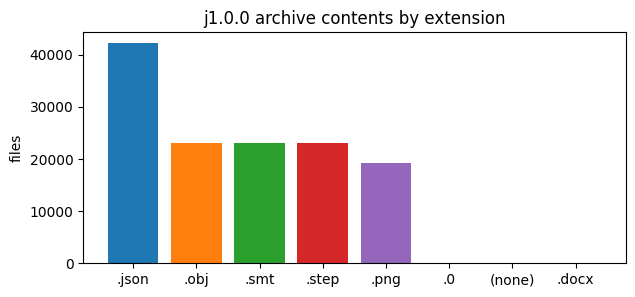

In [6]:
# What is inside the archive? py7zr reads the central directory only (fast),
# so this is cheap even before anything is extracted. Raw names first - this
# is the ground truth for the layout, independent of what the docs say.
with py7zr.SevenZipFile(archive_path, mode="r") as _archive:
    names = _archive.getnames()
print(f"{len(names)} members total\n")
print("first 20 member names:")
for n in names[:20]:
    print(" ", n)

ext_counts = collections.Counter(
    os.path.splitext(n)[1] for n in names if not n.endswith("/")
)
exts, counts = zip(*ext_counts.most_common())
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(
    range(len(exts)), counts,
    color=plt.get_cmap("tab10").colors[: len(exts)],
    tick_label=[e or "(none)" for e in exts],
)
ax.set_ylabel("files")
ax.set_title("j1.0.0 archive contents by extension")
plt.show()

In [12]:
# Real layout (confirmed from a live inventory): flat under j1.0.0/joint/,
# not nested per-assembly folders, and there's no combined "assembly.*" file
# - Autodesk's docs described the full Assembly dataset, not this joint-only
# slice. Each joint SAMPLE is one design id (e.g. "100218_83ec552f_0000")
# with one file set PER BODY, the body index being the last underscore
# segment ("_1", "_2", ...): 100218_83ec552f_0000_1.obj is body 1,
# 100218_83ec552f_0000_2.obj is body 2 of the same joint. Group by
# stripping that last segment.
joint_names = [n for n in names if n.startswith("j1.0.0/joint/")]

by_joint = collections.defaultdict(list)
for n in joint_names:
    stem = os.path.splitext(os.path.basename(n))[0]
    base, _, _body_index = stem.rpartition("_")
    by_joint[base].append(n)

print(f"{len(joint_names)} files under j1.0.0/joint/")
print(f"{len(by_joint)} joint samples (design + body-pair) detected")
example_id = next(iter(by_joint))
print("example:", example_id, "->", sorted(by_joint[example_id]))

130429 files under j1.0.0/joint/
15593 joint samples (design + body-pair) detected
example: 100218_83ec552f_0000 -> ['j1.0.0/joint/100218_83ec552f_0000_1.json', 'j1.0.0/joint/100218_83ec552f_0000_1.obj', 'j1.0.0/joint/100218_83ec552f_0000_1.smt', 'j1.0.0/joint/100218_83ec552f_0000_1.step', 'j1.0.0/joint/100218_83ec552f_0000_2.json', 'j1.0.0/joint/100218_83ec552f_0000_2.obj', 'j1.0.0/joint/100218_83ec552f_0000_2.smt', 'j1.0.0/joint/100218_83ec552f_0000_2.step']


In [13]:
# Pull one joint sample's files out and look at them.
SAMPLE_DIR = (
    Path("/content/sample_assembly") if IN_COLAB
    else Path(REPO_DIR) / "data" / "sample_assembly"
)

if not by_joint:
    print("skipped: no joint samples identified above")
else:
    sample_id = example_id
    sample_members = sorted(by_joint[sample_id])
    print(f"{sample_id}  ({len(sample_members)} files)")
    for m in sample_members:
        print("  ", m)

    json_members = [m for m in sample_members if m.endswith(".json")]
    if not json_members:
        print("\nno .json in this sample - can't peek at the schema")
    else:
        with py7zr.SevenZipFile(archive_path, mode="r") as _archive:
            _archive.extract(path=SAMPLE_DIR, targets=json_members)
        for jm in json_members:
            data = json.loads((SAMPLE_DIR / jm).read_text())
            print(f"\n{jm} top-level keys:", list(data))

100218_83ec552f_0000  (8 files)
   j1.0.0/joint/100218_83ec552f_0000_1.json
   j1.0.0/joint/100218_83ec552f_0000_1.obj
   j1.0.0/joint/100218_83ec552f_0000_1.smt
   j1.0.0/joint/100218_83ec552f_0000_1.step
   j1.0.0/joint/100218_83ec552f_0000_2.json
   j1.0.0/joint/100218_83ec552f_0000_2.obj
   j1.0.0/joint/100218_83ec552f_0000_2.smt
   j1.0.0/joint/100218_83ec552f_0000_2.step

j1.0.0/joint/100218_83ec552f_0000_1.json top-level keys: ['directed', 'multigraph', 'graph', 'nodes', 'links', 'properties']

j1.0.0/joint/100218_83ec552f_0000_2.json top-level keys: ['directed', 'multigraph', 'graph', 'nodes', 'links', 'properties']


## Takeaways

- The archive is cached on Drive at `raw/j1.0.0.7z` and unpacked nowhere yet -
  same "keep it compressed, extract only what's needed" discipline as the
  reconstruction dataset, since Drive is slow at reading many small files.
- The extension histogram and the assembly-folder count above are the real
  numbers for this archive - update this notebook's docstring once confirmed,
  since the "8,251 / 154,468" figures quoted earlier were for the full
  Assembly collection, not necessarily this joint-only slice.
- **Open question this notebook does not resolve:** whether every assembly
  folder actually has a single combined `assembly.obj` usable like the
  reconstruction dataset's final mesh, or whether some assemblies only ship
  per-body UUID meshes that need composing first. Check the sample folder's
  file list above - if `assembly.obj` is missing there, notebook 03's render
  pipeline needs a merge step before it can treat assembly designs like
  reconstruction designs.

Next: once the layout is confirmed, the reconstruction+assembly combined
dataset build (the notebook 03 equivalent for this data) can start.